# Section 2: Fraud Detection with Decision Trees

**Objective:** Detect fraudulent transactions based on patterns in financial data.

This notebook:
- Loads a *fraud detection* dataset.
- Preprocesses and encodes features.
- Engineers new features from transaction data.
- Trains a **Decision Tree Classifier**.
- Evaluates with **Precision, Recall, F1-score**.
- Provides recommendations for improvement.


In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

# Load dataset
data_path = Path("fraud_detection.csv")
df = pd.read_csv(data_path)

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()


Rows: 1000, Columns: 4


,TransactionID,Amount,Type,IsFraud
0,1,119.39,Debit,0
1,2,23.41,Credit,0
2,3,50.36,Credit,0
3,4,61.59,Online,0
4,5,18.36,Online,0


## Quick Data Inspection

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionID  1000 non-null   int64  
 1   Amount         1000 non-null   float64
 2   Type           1000 non-null   object 
 3   IsFraud        1000 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 31.4+ KB


In [3]:
df.isnull().sum()

TransactionID    0
Amount           0
Type             0
IsFraud          0
dtype: int64

## Preprocessing
Convert categorical features into numerical using Label Encoding.

In [4]:
encoder = LabelEncoder()
df['Type_encoded'] = encoder.fit_transform(df['Type'])
df[['Type', 'Type_encoded']].head()

,Type,Type_encoded
0,Debit,1
1,Credit,0
2,Credit,0
3,Online,2
4,Online,2


## Feature Engineering
We derive new features from existing ones:
- `HighAmount`: whether the amount is above a threshold (e.g., 500)
- `Amount_Log`: log transformation of Amount to reduce skewness


In [5]:
df['HighAmount'] = (df['Amount'] > 500).astype(int)
df['Amount_Log'] = np.log1p(df['Amount'])
df.head()

,TransactionID,Amount,Type,IsFraud,Type_encoded,HighAmount,Amount_Log
0,1,119.39,Debit,0,1,0,4.790736
1,2,23.41,Credit,0,0,0,3.194993
2,3,50.36,Credit,0,0,0,3.938860
3,4,61.59,Online,0,2,0,4.136606
4,5,18.36,Online,0,2,0,2.963209


## Train Decision Tree Classifier

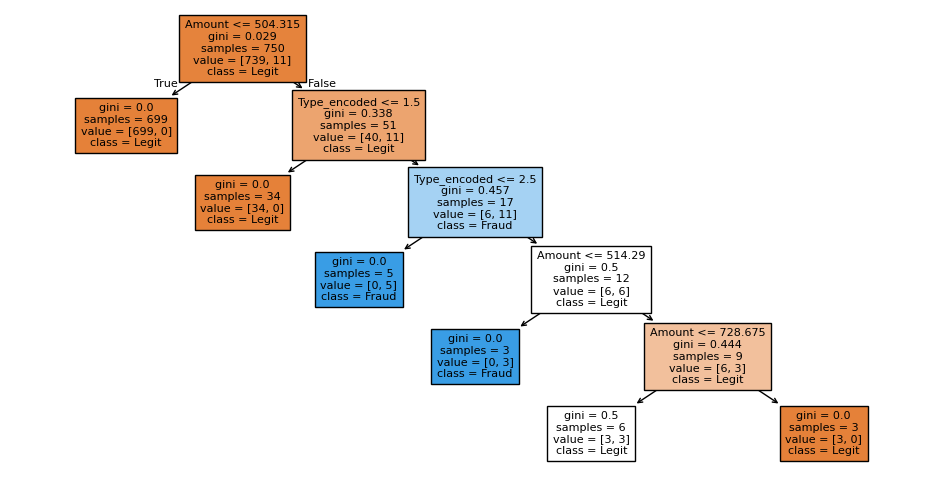

In [6]:
# Features and target
X = df[['Amount','Type_encoded','HighAmount','Amount_Log']]
y = df['IsFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train model
clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

# Visualize tree
plt.figure(figsize=(12,6))
plot_tree(clf, feature_names=X.columns, class_names=['Legit','Fraud'], filled=True, fontsize=8)
plt.show()


## Model Evaluation

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       247
           1       1.00      0.33      0.50         3

    accuracy                           0.99       250
   macro avg       1.00      0.67      0.75       250
weighted avg       0.99      0.99      0.99       250

Precision: 1.000, Recall: 0.333, F1: 0.500


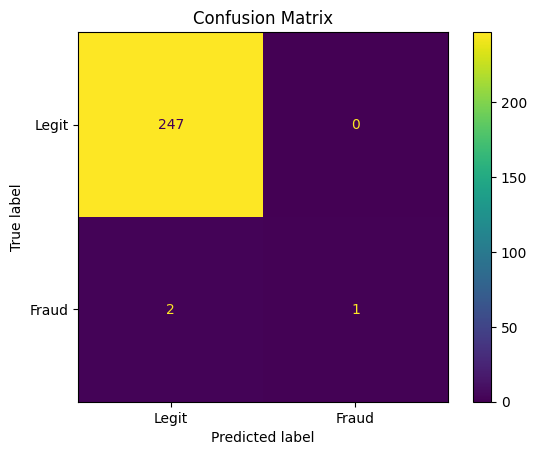

In [7]:
y_pred = clf.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classification Report:\n", classification_report(y_test, y_pred))
print(f"Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit','Fraud'])
disp.plot(values_format='d')
plt.title('Confusion Matrix')
plt.show()


## Recommendations for Improvement
- Collect **more features** (transaction time, location, device info).
- Try **ensemble methods** (Random Forest, Gradient Boosting) for higher accuracy.
- Use **SMOTE or class weighting** to handle class imbalance if fraud cases are rare.
- Monitor **Precision-Recall tradeoff**: in fraud detection, recall (catching fraud) is often more important than raw accuracy.
